In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from datetime import datetime

In [20]:
file_path = '/content/UST Data Sample (July - Sept 2024).xlsx'
df = pd.read_excel(file_path)

# Data Information

In [21]:
df.columns

Index(['let me tak', 'Id', 'Client', 'RFQStatus', 'InstrumentSubGroup',
       'Market Traded Vol (USD)', 'Our Traded Vol', 'TiedWonVol',
       'Num of Dealers', 'Trader', 'Sales', 'Covered Vol', 'ActionStr', 'Tier',
       'InstrumentCode', 'InstrumentDescription', 'AssetClass', 'Market',
       'LegNo', 'Maturity Date', 'RFQNumberOfQuotes', 'Buy/Sell',
       'Best Bid Price', 'Mid Price', 'Best Ask Price', 'Deal Value',
       'AwayFromMid', 'TickIdentifier', 'Deal Spread', 'Cover', 'CoverPnL',
       'SettlementDays', 'SettlementDate', 'SettlementStops', 'RFQ CreateTime',
       'RFQ ClosedTime', 'AnAutoReplyRFQs', 'First Response Time (Sec)',
       'TradeSizeBucket', 'Sector', 'MaturityBucket'],
      dtype='object')

In [22]:
len(df)

66681

In [23]:
df.head(10)

,let me tak,Id,Client,RFQStatus,InstrumentSubGroup,Market Traded Vol (USD),Our Traded Vol,TiedWonVol,Num of Dealers,Trader,...,SettlementDays,SettlementDate,SettlementStops,RFQ CreateTime,RFQ ClosedTime,AnAutoReplyRFQs,First Response Time (Sec),TradeSizeBucket,Sector,MaturityBucket
0,2024-09-30,66FA7D45432800D20002,Client1,Done,OFFTHERUN,100000000,100000000,100000000,6,Trader1,...,1,2024-10-01,T+1,2024-09-30 06:28:00,2024-09-30 06:28:00,1,0.03,50+M,5-7 YR,5y-7y
1,2024-09-30,TRSY_20240930_15961,Client2,Done,"OFFTHERUN,DOUBLEOLDS",2100000,2100000,2100000,5,Trader2,...,1,2024-10-01,T+1,2024-09-30 16:00:00,2024-09-30 16:00:00,1,0.95,1-5M,7-10 YR,7y-10y
2,2024-09-30,TRSY_20240930_314,Client2,Done,ONTHERUN,53000000,53000000,53000000,5,Trader3,...,1,2024-10-01,T+1,2024-09-30 15:46:00,2024-09-30 15:46:00,1,0.07,50+M,7-10 YR,7y-10y
3,2024-09-30,66FAEA57432800020001,Client3,Done,OFFTHERUN,500000,500000,500000,5,Trader4,...,1,2024-10-01,T+1,2024-09-30 14:14:00,2024-09-30 14:14:00,1,0.03,500K-1M,0-1 YR,<18mos
4,2024-09-30,66FAC35D455C00210006,Client4,Done,OFFTHERUN,1058000,1058000,1058000,5,Trader2,...,1,2024-10-01,T+1,2024-09-30 11:27:00,2024-09-30 11:27:00,1,0.03,1-5M,5-7 YR,3y-5y
5,2024-09-30,66FB01C6432800130001,Client4,Done,ONTHERUN,25000000,25000000,0,5,Trader4,...,1,2024-10-01,T+1,2024-09-30 15:53:00,2024-09-30 15:54:00,0,13.28,25-50M,BILLS,<18mos
6,2024-09-30,66FAFF05432800000001,Client5,Done,ONTHERUN,1132000,1132000,0,1,Trader2,...,1,2024-10-01,T+1,2024-09-30 15:42:00,2024-09-30 15:42:00,1,0.03,1-5M,5-7 YR,5y-7y
7,2024-09-30,66FAEFC145C4000A0001,Client5,Done,ONTHERUN,818000,818000,0,1,Trader2,...,1,2024-10-01,T+1,2024-09-30 14:36:00,2024-09-30 14:36:00,1,0.03,500K-1M,7-10 YR,7y-10y
8,2024-09-30,66FA9F0D45C400400001,Client5,Done,ONTHERUN,500000,500000,0,1,Trader2,...,1,2024-10-01,T+1,2024-09-30 08:53:00,2024-09-30 08:53:00,1,0.03,500K-1M,3-5 YR,3y-5y
9,2024-09-30,66FB0D0C45C400000001,Client5,Done,ONTHERUN,500000,500000,500000,5,Trader2,...,1,2024-10-01,T+1,2024-09-30 16:41:00,2024-09-30 16:41:00,1,0.04,500K-1M,7-10 YR,7y-10y


In [24]:
df.describe()

,let me tak,Market Traded Vol (USD),Our Traded Vol,TiedWonVol,Num of Dealers,Covered Vol,LegNo,Maturity Date,RFQNumberOfQuotes,Best Bid Price,...,Deal Value,AwayFromMid,Deal Spread,Cover,SettlementDays,SettlementDate,RFQ CreateTime,RFQ ClosedTime,AnAutoReplyRFQs,First Response Time (Sec)
count,66681,6.668100e+04,6.668100e+04,6.668100e+04,66681.000000,6.668100e+04,66681.000000,66681,66681.000000,66681.000000,...,66681.000000,6.668100e+04,66681.000000,66681.000000,66681.000000,66681,66681,66681,66681.000000,66681.000000
mean,2024-08-16 21:24:50.241598208,9.103470e+06,1.302165e+06,1.783406e+05,6.112476,1.664401e+06,0.017756,1997-09-29 08:14:00.923201664,4.417180,62.295291,...,-71.022155,1.655243e+05,0.080674,1.951735,1.050989,2024-08-18 08:40:50.209205248,2024-08-17 08:42:32.188779264,2024-08-17 08:42:42.610338816,0.640242,1.140302
min,2024-07-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,0.000000e+00,0.000000,1930-01-15 00:00:00,0.000000,0.000000,...,-999999.000000,0.000000e+00,-531.980000,-45.300000,0.000000,2024-07-01 00:00:00,2024-07-01 04:01:00,2024-07-01 04:01:00,0.000000,0.000000
25%,2024-07-25 00:00:00,6.000000e+05,0.000000e+00,0.000000e+00,4.000000,0.000000e+00,0.000000,1951-11-15 00:00:00,1.000000,5.140000,...,5.150000,1.280000e+00,0.000000,0.000000,1.000000,2024-07-26 00:00:00,2024-07-25 13:18:00,2024-07-25 13:18:00,0.000000,0.020000
50%,2024-08-16 00:00:00,1.500000e+06,0.000000e+00,0.000000e+00,5.000000,0.000000e+00,0.000000,2024-10-22 00:00:00,2.000000,97.558594,...,98.050781,3.000000e+00,0.000000,0.000000,1.000000,2024-08-19 00:00:00,2024-08-16 08:35:00,2024-08-16 08:35:00,1.000000,0.030000
75%,2024-09-10 00:00:00,5.000000e+06,0.000000e+00,0.000000e+00,7.000000,0.000000e+00,0.000000,2025-07-10 00:00:00,4.000000,100.628906,...,100.687500,7.000000e+00,0.000000,0.000000,1.000000,2024-09-11 00:00:00,2024-09-10 12:01:00,2024-09-10 12:01:00,1.000000,0.050000
max,2024-09-30 00:00:00,1.486000e+09,9.000000e+08,5.000000e+08,22.000000,6.750000e+08,2.000000,2029-12-31 00:00:00,90.000000,114.351562,...,999999.000000,2.559997e+08,458.440000,113.832031,10.000000,2024-10-04 00:00:00,2024-09-30 16:58:00,2024-09-30 16:58:00,1.000000,109.090000
std,NaN,3.280953e+07,1.424713e+07,4.730946e+06,4.085569,1.366841e+07,0.138170,NaN,8.314328,46.111660,...,25394.307745,6.498830e+06,12.307430,13.714968,0.579735,NaN,NaN,NaN,0.479933,3.747233


In [25]:
missing_values = df.isnull().sum()
missing_values

,0
let me tak,0
Id,0
Client,0
RFQStatus,0
InstrumentSubGroup,0
Market Traded Vol (USD),0
Our Traded Vol,0
TiedWonVol,0
Num of Dealers,0
Trader,0


In [26]:
df.dropna(inplace=True)

In [27]:
len(df['Client'].unique())

928

In [28]:
len(df['Trader'].unique())

9

In [29]:
# Count of "TFRNS"
tfrns_count = df[df['AssetClass'] == 'TFRNS'].shape[0]

print(f'Total number of TFRNS in AssetClass column: {tfrns_count}')

Total number of TFRNS in AssetClass column: 64


In [30]:
df = df[df['AssetClass'] != 'TFRNS']

In [31]:
df.head(80)

,let me tak,Id,Client,RFQStatus,InstrumentSubGroup,Market Traded Vol (USD),Our Traded Vol,TiedWonVol,Num of Dealers,Trader,...,SettlementDays,SettlementDate,SettlementStops,RFQ CreateTime,RFQ ClosedTime,AnAutoReplyRFQs,First Response Time (Sec),TradeSizeBucket,Sector,MaturityBucket
0,2024-09-30,66FA7D45432800D20002,Client1,Done,OFFTHERUN,100000000,100000000,100000000,6,Trader1,...,1,2024-10-01,T+1,2024-09-30 06:28:00,2024-09-30 06:28:00,1,0.03,50+M,5-7 YR,5y-7y
1,2024-09-30,TRSY_20240930_15961,Client2,Done,"OFFTHERUN,DOUBLEOLDS",2100000,2100000,2100000,5,Trader2,...,1,2024-10-01,T+1,2024-09-30 16:00:00,2024-09-30 16:00:00,1,0.95,1-5M,7-10 YR,7y-10y
2,2024-09-30,TRSY_20240930_314,Client2,Done,ONTHERUN,53000000,53000000,53000000,5,Trader3,...,1,2024-10-01,T+1,2024-09-30 15:46:00,2024-09-30 15:46:00,1,0.07,50+M,7-10 YR,7y-10y
3,2024-09-30,66FAEA57432800020001,Client3,Done,OFFTHERUN,500000,500000,500000,5,Trader4,...,1,2024-10-01,T+1,2024-09-30 14:14:00,2024-09-30 14:14:00,1,0.03,500K-1M,0-1 YR,<18mos
4,2024-09-30,66FAC35D455C00210006,Client4,Done,OFFTHERUN,1058000,1058000,1058000,5,Trader2,...,1,2024-10-01,T+1,2024-09-30 11:27:00,2024-09-30 11:27:00,1,0.03,1-5M,5-7 YR,3y-5y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,2024-09-30,66FAF945483000150001,Client38,Done,ONTHERUN,24500000,24500000,0,5,Trader4,...,1,2024-10-01,T+1,2024-09-30 15:18:00,2024-09-30 15:18:00,0,4.50,10-25M,BILLS,<18mos
76,2024-09-30,66FAF8C9483000000001,Client38,Done,ONTHERUN,24500000,24500000,0,5,Trader4,...,1,2024-10-01,T+1,2024-09-30 15:16:00,2024-09-30 15:16:00,0,5.15,10-25M,BILLS,<18mos
77,2024-09-30,TRSY_20240930_1427,Client39,Done,"OFFTHERUN,OLDBONDS",5620000,5620000,0,1,Trader3,...,1,2024-10-01,T+1,2024-09-30 11:27:00,2024-09-30 11:27:00,0,0.06,5-10M,15-30 YR,10-30y
78,2024-09-30,TRSY_20240930_3079,Client39,Done,"OFFTHERUN,OLDBONDS",1810000,1810000,0,1,Trader2,...,1,2024-10-01,T+1,2024-09-30 09:05:00,2024-09-30 09:05:00,0,0.06,1-5M,15-30 YR,10-30y


In [32]:
def convert_year(row):
    year = row.year  # Extract the year
    month = row.month  # Extract the month
    day = row.day  # Extract the day
    if year < 2000:
        year += 100  # Convert 19xx to 20xx
    return pd.Timestamp(year=year, month=month, day=day)

# Apply the conversion function to the 'Maturity Date' column
df['Maturity Date'] = df['Maturity Date'].apply(convert_year)

# Print the updated DataFrame
print(df)


      let me tak                    Id     Client        RFQStatus  \
0     2024-09-30  66FA7D45432800D20002    Client1             Done   
1     2024-09-30   TRSY_20240930_15961    Client2             Done   
2     2024-09-30     TRSY_20240930_314    Client2             Done   
3     2024-09-30  66FAEA57432800020001    Client3             Done   
4     2024-09-30  66FAC35D455C00210006    Client4             Done   
...          ...                   ...        ...              ...   
66676 2024-07-01  E68302E5454C00010001   Client33  CustomerTimeOut   
66677 2024-07-01  E68305CA57D000080001   Client33  CustomerTimeOut   
66678 2024-07-01  E683099657D000010001   Client33  CustomerTimeOut   
66679 2024-07-01  6682BE1857D0000C0002  Client271  CustomerTimeOut   
66680 2024-07-01  6682D14445CC00050001   Client38  CustomerTimeOut   

         InstrumentSubGroup  Market Traded Vol (USD)  Our Traded Vol  \
0                 OFFTHERUN                100000000       100000000   
1      OFFTHERU

In [33]:
df['Maturity Date'].unique()

<DatetimeArray>
['2030-04-30 00:00:00', '2034-02-15 00:00:00', '2031-09-30 00:00:00',
 '2025-09-15 00:00:00', '2028-06-30 00:00:00', '2024-10-29 00:00:00',
 '2029-09-30 00:00:00', '2027-09-15 00:00:00', '2034-08-15 00:00:00',
 '2044-08-15 00:00:00',
 ...
 '2034-11-15 00:00:00', '2024-07-23 00:00:00', '2024-07-18 00:00:00',
 '2037-08-15 00:00:00', '2024-07-16 00:00:00', '2024-07-15 00:00:00',
 '2024-07-11 00:00:00', '2024-07-09 00:00:00', '2024-07-05 00:00:00',
 '2024-07-02 00:00:00']
Length: 319, dtype: datetime64[ns]

In [34]:
# Function to calculate years to maturity
def calculate_years_to_maturity(row):
    maturity_date = pd.to_datetime(row['Maturity Date'])
    trade_date = pd.to_datetime(row['let me tak'])
    return (maturity_date - trade_date).days / 365.25

df['Years to Maturity'] = df.apply(calculate_years_to_maturity, axis=1)


def extract_yield(description):
    match = re.search(r"(\d+\.\d+)", description)
    return float(match.group(1)) if match else np.nan  # Return NaN if no match is found

df['Yield'] = df['InstrumentDescription'].apply(extract_yield)

def yield_to_price(ytm, years_to_maturity, face_value=100):
    if pd.isna(ytm) or pd.isna(years_to_maturity):
        return np.nan
    return face_value / ((1 + 0.01 * ytm) ** years_to_maturity)

def bill_price(face_value, deal_price, days_to_maturity):
    if pd.isna(deal_price) or pd.isna(days_to_maturity):
        return np.nan
    discount_yield = ((face_value - deal_price) / face_value) * (360 / days_to_maturity)
    return face_value * (1 - (discount_yield / 100) * (days_to_maturity / 360))

# Columns to convert
columns_to_convert = ['Best Bid Price', 'Mid Price', 'Best Ask Price', 'Deal Value', 'Cover']

for column in columns_to_convert:
    df[f'Converted {column}'] = df.apply(
        lambda row: (
            # yield_to_price(row['Yield'], row['Years to Maturity']) if row['AssetClass'] == 'STRIPS'
            # else (
                bill_price(100, row[column], (pd.to_datetime(row['Maturity Date']) - pd.to_datetime(row['let me tak'])).days)
                if (row['AssetClass'] == 'BILLS' or row['AssetClass'] == 'STRIPS')else row[column]
            # )
        ),
        axis=1
    )

print(df[['InstrumentDescription', 'AssetClass', 'Yield', 'Years to Maturity'] + [f'Converted {col}' for col in columns_to_convert]])

        InstrumentDescription AssetClass  Yield  Years to Maturity  \
0           T  3.500 04/30/30      BONDS  3.500           5.579740   
1           T  4.000 02/15/34      BONDS  4.000           9.377139   
2      T  3.625 09/30/31  7YR      BONDS  3.625           6.997947   
3           T  3.500 09/15/25      BONDS  3.500           0.958248   
4           T  4.000 06/30/28      BONDS  4.000           3.748118   
...                       ...        ...    ...                ...   
66676        B  09/26/24  3MO      BILLS    NaN           0.238193   
66677        B  09/26/24  3MO      BILLS    NaN           0.238193   
66678        B  09/26/24  3MO      BILLS    NaN           0.238193   
66679       T  1.000 12/15/24      BONDS  1.000           0.457221   
66680             B  07/02/24      BILLS    NaN           0.002738   

       Converted Best Bid Price  Converted Mid Price  \
0                     99.539062            99.550781   
1                    101.712388           101.7

In [35]:
# Filter the DataFrame for AssetClass that is either BILLS or STRIPS
bills_strips_df = df[df['AssetClass'].isin(['BILLS', 'STRIPS', 'BONDS'])]

# Select only the columns that are related to converted prices
columns_to_display = ['InstrumentDescription', 'AssetClass', 'Yield', 'Years to Maturity'] + [f'Converted {col}' for col in columns_to_convert]

# Display the filtered DataFrame with the desired columns
print(bills_strips_df[columns_to_display].head(30))

      InstrumentDescription AssetClass  Yield  Years to Maturity  \
0         T  3.500 04/30/30      BONDS  3.500           5.579740   
1         T  4.000 02/15/34      BONDS  4.000           9.377139   
2    T  3.625 09/30/31  7YR      BONDS  3.625           6.997947   
3         T  3.500 09/15/25      BONDS  3.500           0.958248   
4         T  4.000 06/30/28      BONDS  4.000           3.748118   
5          B  10/29/24  1MO      BILLS    NaN           0.079398   
6    T  3.500 09/30/29  5YR      BONDS  3.500           4.999316   
7    T  3.625 09/30/31  7YR      BONDS  3.625           6.997947   
8    T  3.375 09/15/27  3YR      BONDS  3.375           2.956879   
9   T  3.875 08/15/34  10YR      BONDS  3.875           9.872690   
10   T  3.500 09/30/29  5YR      BONDS  3.500           4.999316   
11  T  4.125 08/15/44  20YR      BONDS  4.125          19.874059   
12  T  3.875 08/15/34  10YR      BONDS  3.875           9.872690   
13  T  4.250 08/15/54  30YR      BONDS  4.250   

In [36]:
df.columns

Index(['let me tak', 'Id', 'Client', 'RFQStatus', 'InstrumentSubGroup',
       'Market Traded Vol (USD)', 'Our Traded Vol', 'TiedWonVol',
       'Num of Dealers', 'Trader', 'Sales', 'Covered Vol', 'ActionStr', 'Tier',
       'InstrumentCode', 'InstrumentDescription', 'AssetClass', 'Market',
       'LegNo', 'Maturity Date', 'RFQNumberOfQuotes', 'Buy/Sell',
       'Best Bid Price', 'Mid Price', 'Best Ask Price', 'Deal Value',
       'AwayFromMid', 'TickIdentifier', 'Deal Spread', 'Cover', 'CoverPnL',
       'SettlementDays', 'SettlementDate', 'SettlementStops', 'RFQ CreateTime',
       'RFQ ClosedTime', 'AnAutoReplyRFQs', 'First Response Time (Sec)',
       'TradeSizeBucket', 'Sector', 'MaturityBucket', 'Years to Maturity',
       'Yield', 'Converted Best Bid Price', 'Converted Mid Price',
       'Converted Best Ask Price', 'Converted Deal Value', 'Converted Cover'],
      dtype='object')

In [ ]:
def calculate_slippage_price(row):
    if row['Buy/Sell'] == 'Buy':
        return (row['Converted Deal Value'] - row['Converted Mid Price'])
    elif row['Buy/Sell'] == 'Sell':
        return (row['Converted Mid Price'] - row['Converted Deal Value'])
    return None

df['Slippage'] = df.apply(calculate_slippage_price, axis=1)

In [ ]:
df['Spread'] = df['Converted Best Ask Price'] - df['Converted Best Bid Price']

## spread

<ipython-input-23-996f7e640bde>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Tier', y='Spread', palette='tab10')


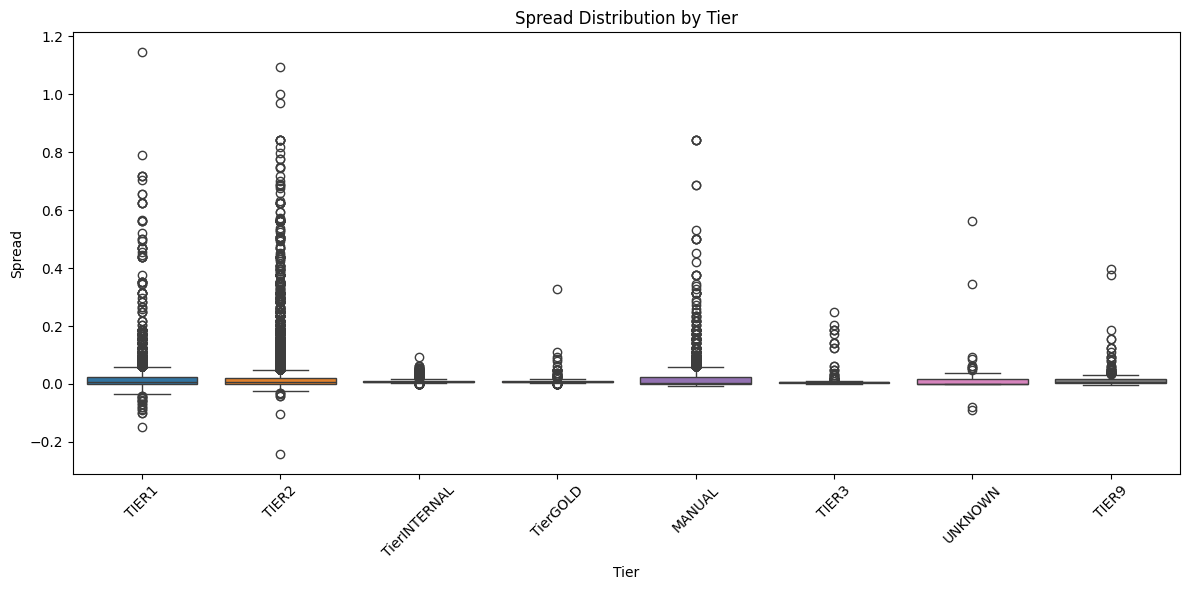

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Tier', y='Spread', palette='tab10')
plt.title('Spread Distribution by Tier')
plt.xlabel('Tier')
plt.ylabel('Spread')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<ipython-input-24-27fa7c8a9e27>:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Tier', y='Spread', palette='tab10', ci=None)
<ipython-input-24-27fa7c8a9e27>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Tier', y='Spread', palette='tab10', ci=None)


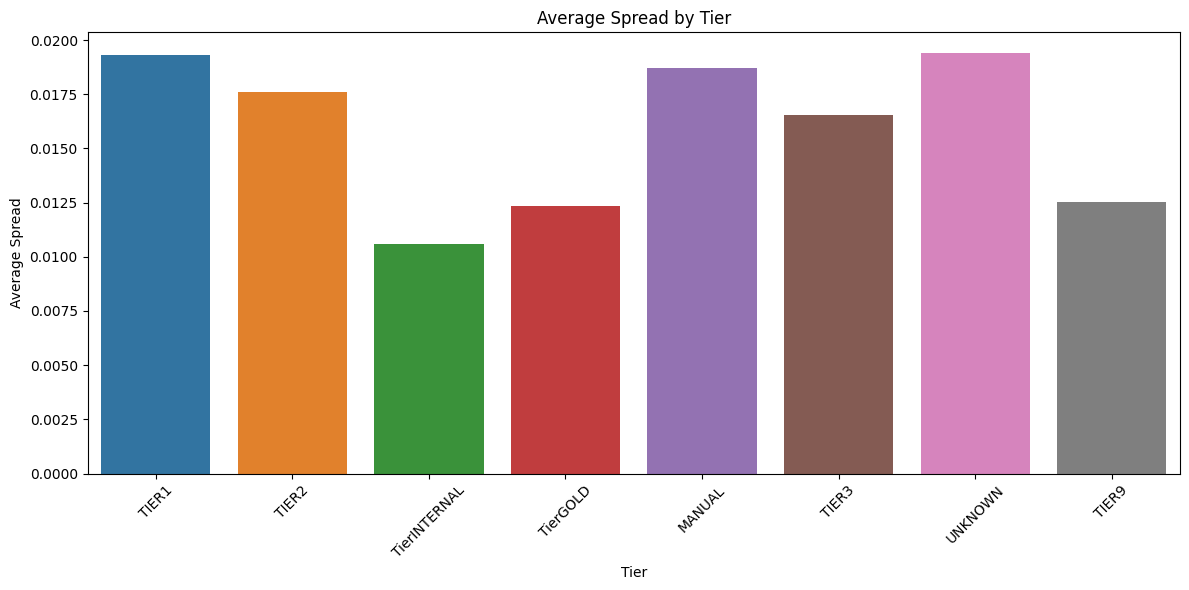

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Tier', y='Spread', palette='tab10', ci=None)
plt.title('Average Spread by Tier')
plt.xlabel('Tier')
plt.ylabel('Average Spread')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<ipython-input-41-df973b5eb2e1>:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Trader', y='Spread', palette='plasma', ci=None)
<ipython-input-41-df973b5eb2e1>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Trader', y='Spread', palette='plasma', ci=None)


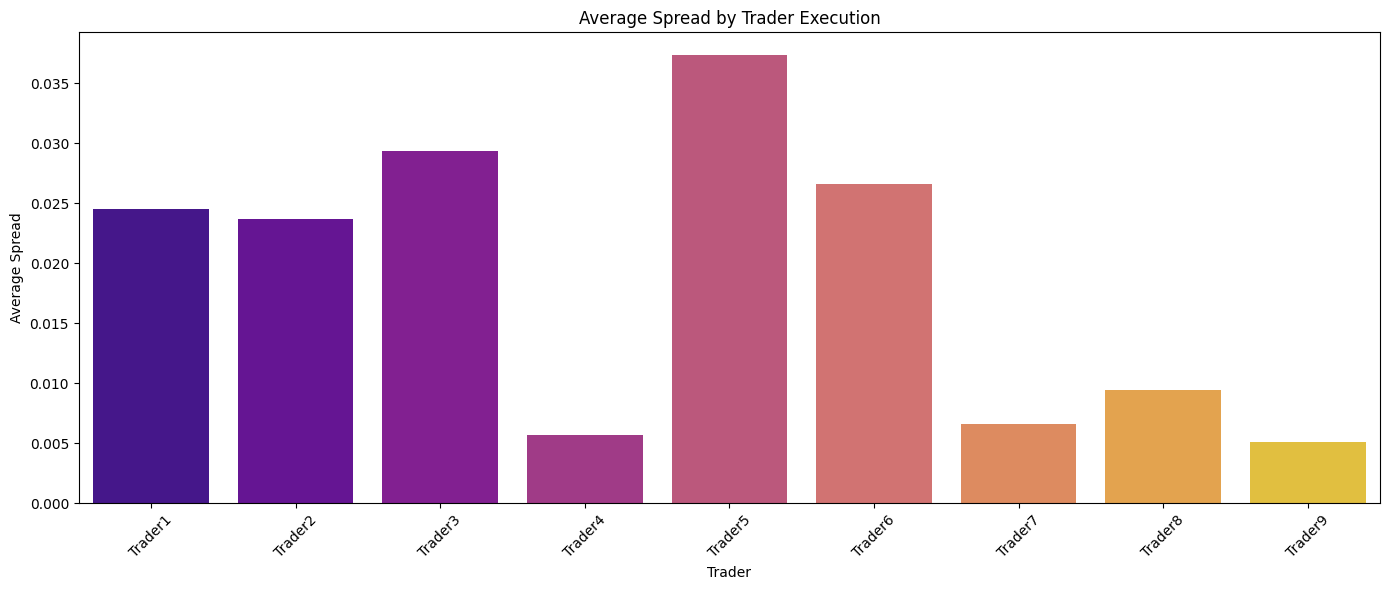

In [ ]:
plt.figure(figsize=(14, 6))
sns.barplot(data=df, x='Trader', y='Spread', palette='plasma', ci=None)
plt.title('Average Spread by Trader Execution')
plt.xlabel('Trader')
plt.ylabel('Average Spread')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## slippage

<ipython-input-42-fcd5daf55fc5>:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Tier', y='Slippage_bps', palette='viridis', ci=None)
<ipython-input-42-fcd5daf55fc5>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Tier', y='Slippage_bps', palette='viridis', ci=None)


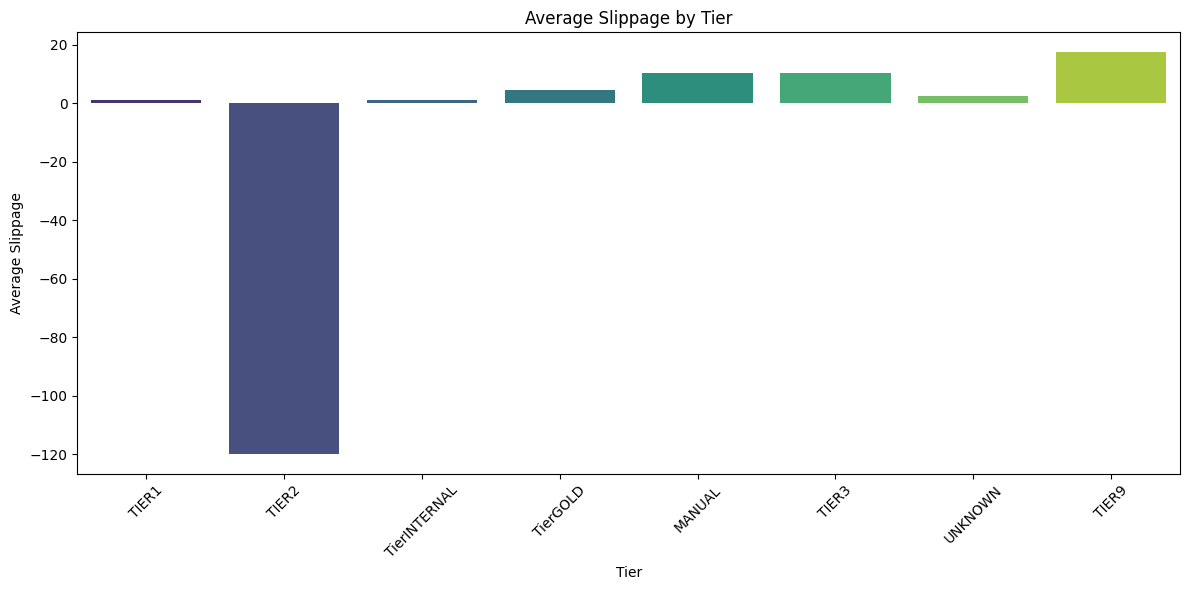

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Tier', y='Slippage_bps', palette='viridis', ci=None)
plt.title('Average Slippage by Tier')
plt.xlabel('Tier')
plt.ylabel('Average Slippage')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<ipython-input-44-0a46e100209b>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='InstrumentSubGroup', y='Converted Deal Value', estimator=sum, palette='Blues')


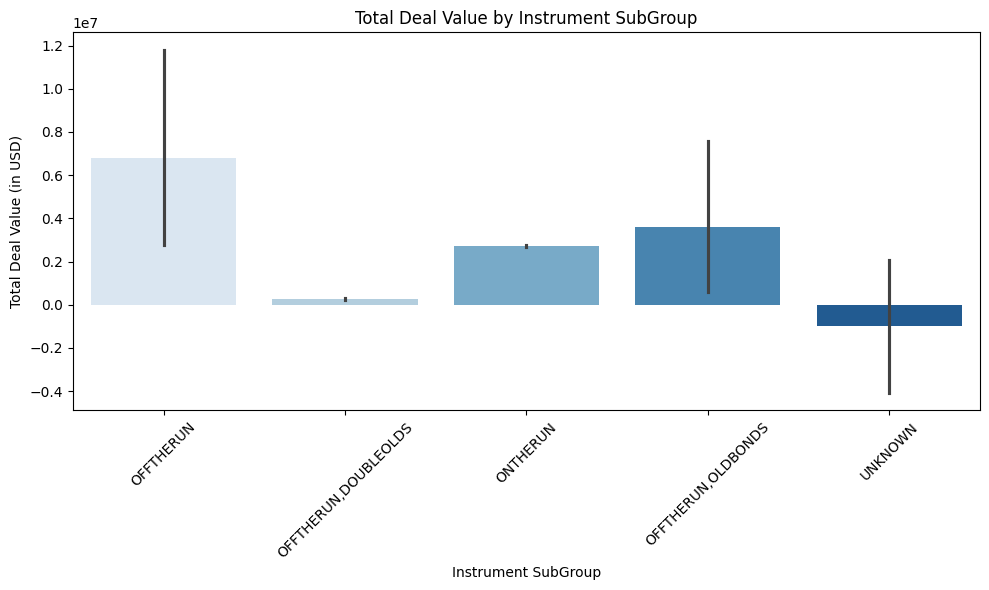

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='InstrumentSubGroup', y='Converted Deal Value', estimator=sum, palette='Blues')
plt.title('Total Deal Value by Instrument SubGroup')
plt.xlabel('Instrument SubGroup')
plt.ylabel('Total Deal Value (in USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Volume analysis for clients

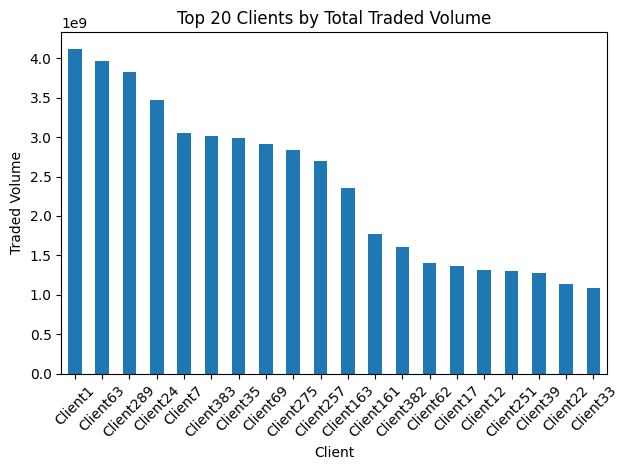

In [ ]:
# Summarize total traded volume by Client
client_volume = df.groupby('Client')['Our Traded Vol'].sum()

N = 20
top_clients = client_volume.nlargest(N)

# Plot the top N clients
top_clients.plot(kind='bar', title=f'Top {N} Clients by Total Traded Volume', xlabel='Client', ylabel='Traded Volume')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df['Our Traded Vol'].describe()

,Our Traded Vol
count,6.617200e+04
mean,1.260139e+06
std,1.394884e+07
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,0.000000e+00
max,9.000000e+08


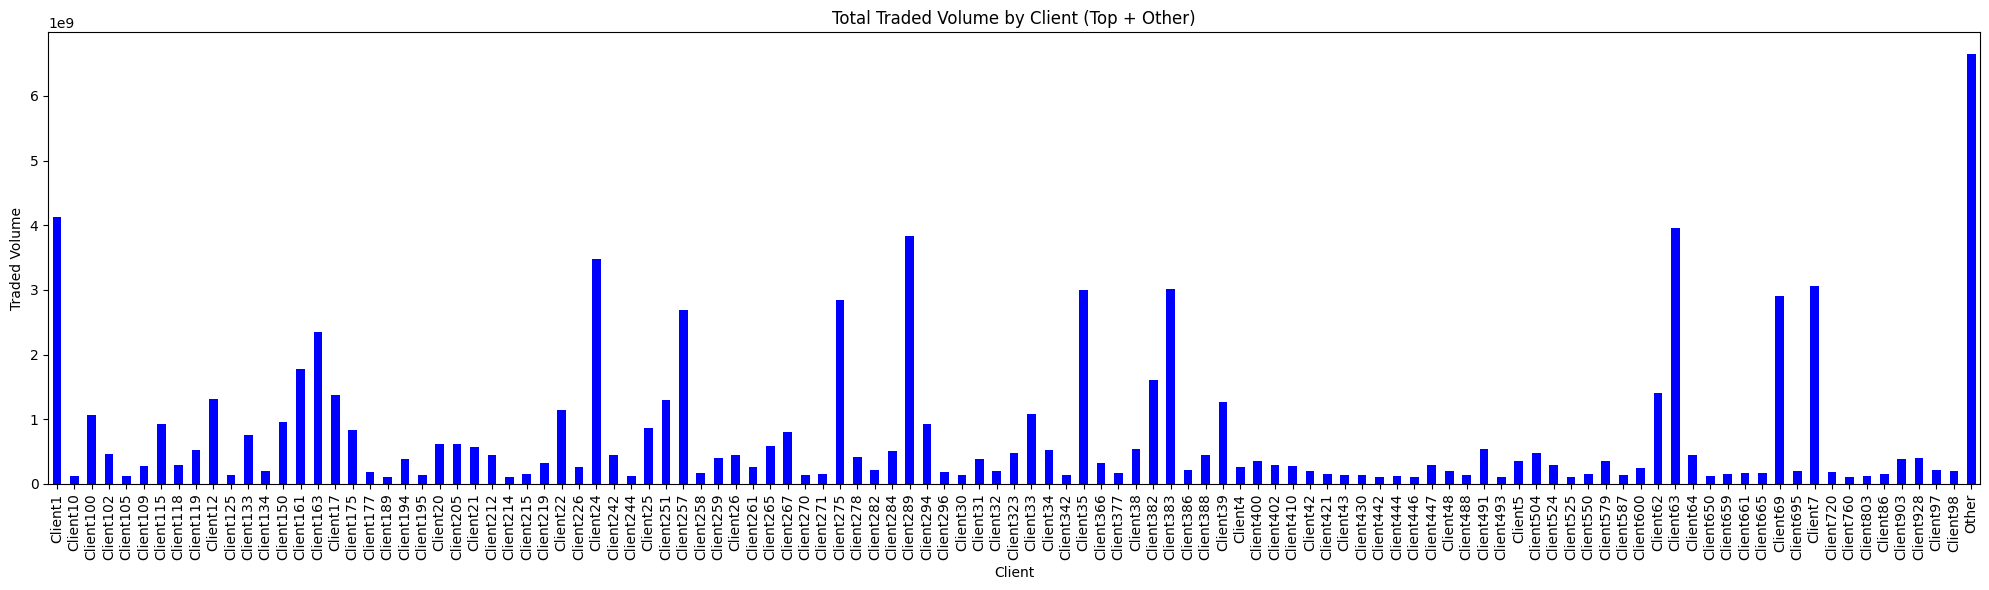

In [ ]:
# Set a threshold for clients to be grouped into 'Other'
threshold = 1e8  # Adjust this value as needed

# Sum total traded volume by client
client_volume = df.groupby('Client')['Our Traded Vol'].sum()

# Separate top clients and group smaller clients into 'Other'
top_clients = client_volume[client_volume >= threshold]
other_clients = client_volume[client_volume < threshold].sum()

# Combine top clients and "Other" using pd.concat
combined_data = pd.concat([top_clients, pd.Series({'Other': other_clients})])

# Plot Total Traded Volume by Client (Top + Other)
plt.figure(figsize=(20, 6))
combined_data.plot(kind='bar', title='Total Traded Volume by Client (Top + Other)', color='blue')
plt.xlabel('Client')
plt.ylabel('Traded Volume')
plt.xticks(rotation=90)  # Rotate x-axis labels for readability
plt.tight_layout()
plt.show()

## Volume analysis for traders

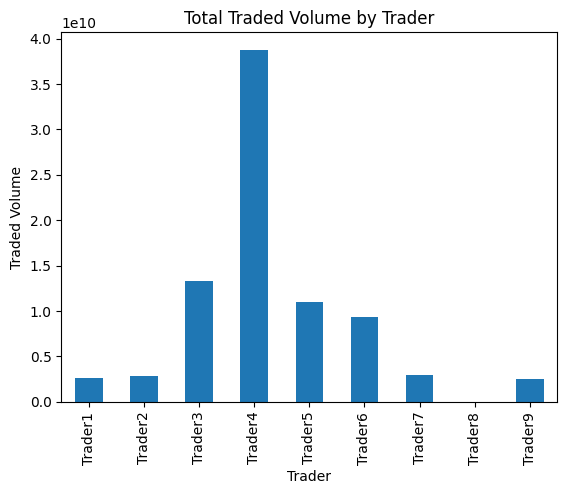

In [ ]:
# for traders
trader_volume = df.groupby('Trader')['Our Traded Vol'].sum()

trader_volume.plot(kind='bar', title='Total Traded Volume by Trader', xlabel='Trader', ylabel='Traded Volume')
plt.show()

## Total pnl, average response time for each trader

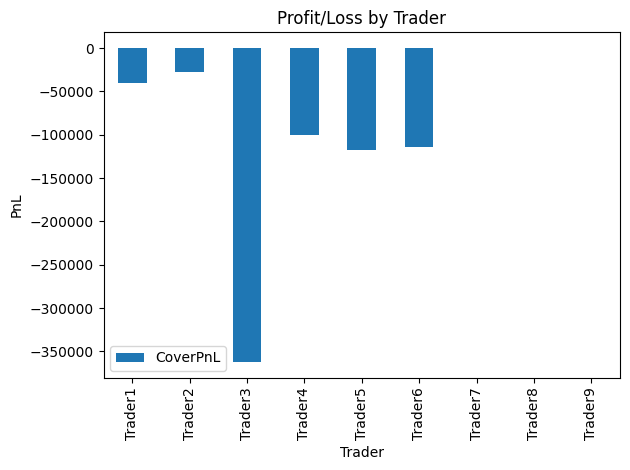

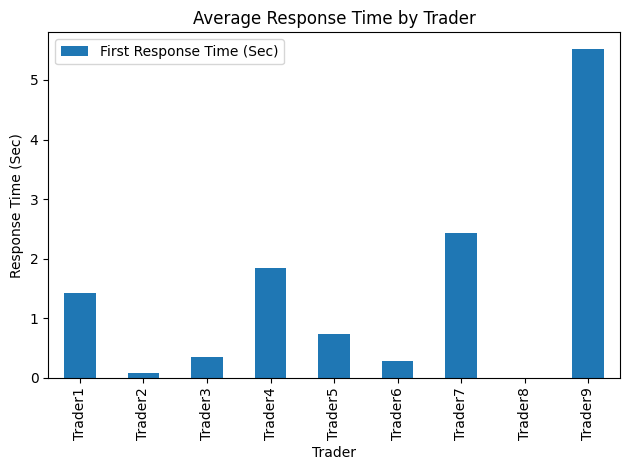

In [ ]:
# Aggregate volume and CoverPnL by trader
trader_data = df.groupby('Trader').agg({
    'CoverPnL': 'sum',
    'First Response Time (Sec)': 'mean'  # Average response time
}).reset_index()

# profitability per trader
trader_data.plot(kind='bar', x='Trader', y='CoverPnL', title='Profit/Loss by Trader', xlabel='Trader', ylabel='PnL')
plt.tight_layout()
plt.show()

# average response time per trader
trader_data.plot(kind='bar', x='Trader', y='First Response Time (Sec)', title='Average Response Time by Trader', xlabel='Trader', ylabel='Response Time (Sec)')
plt.tight_layout()
plt.show()

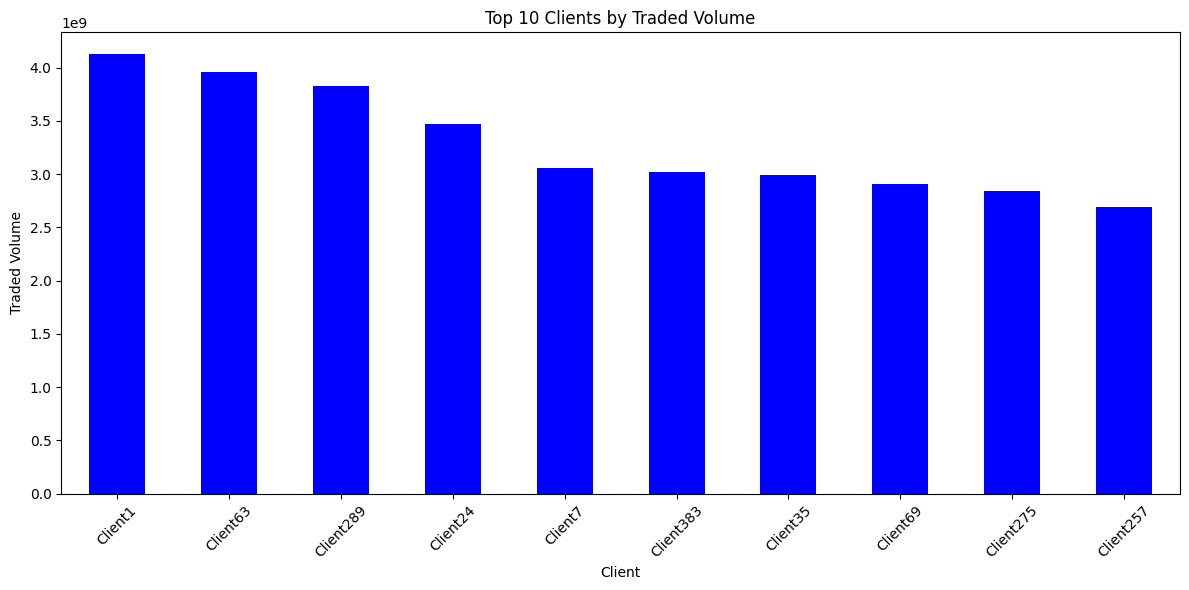

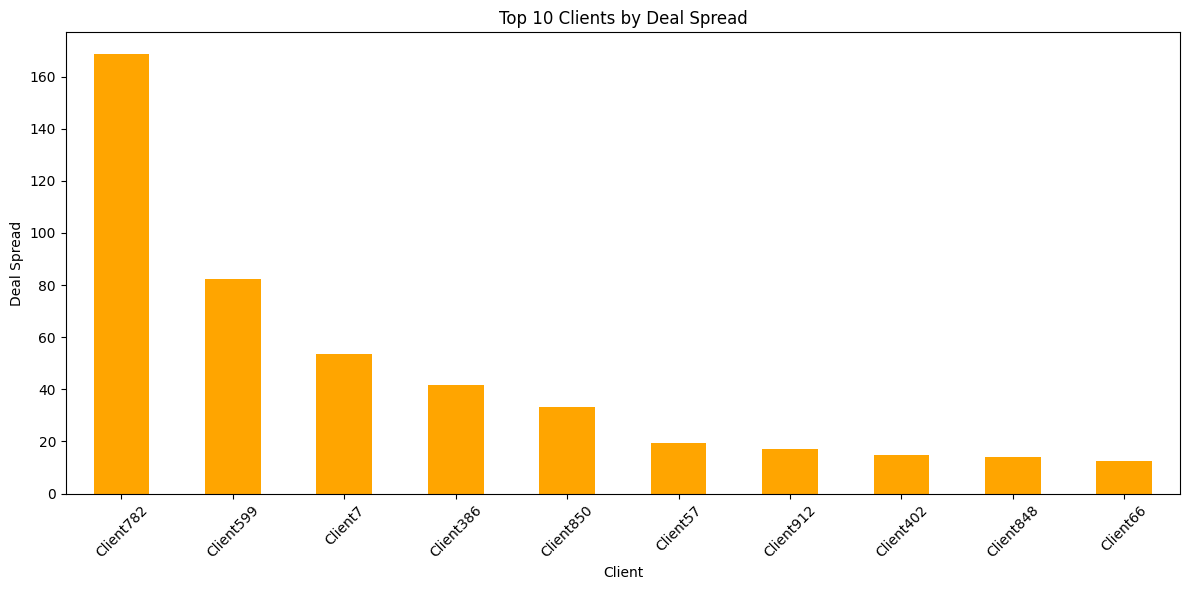

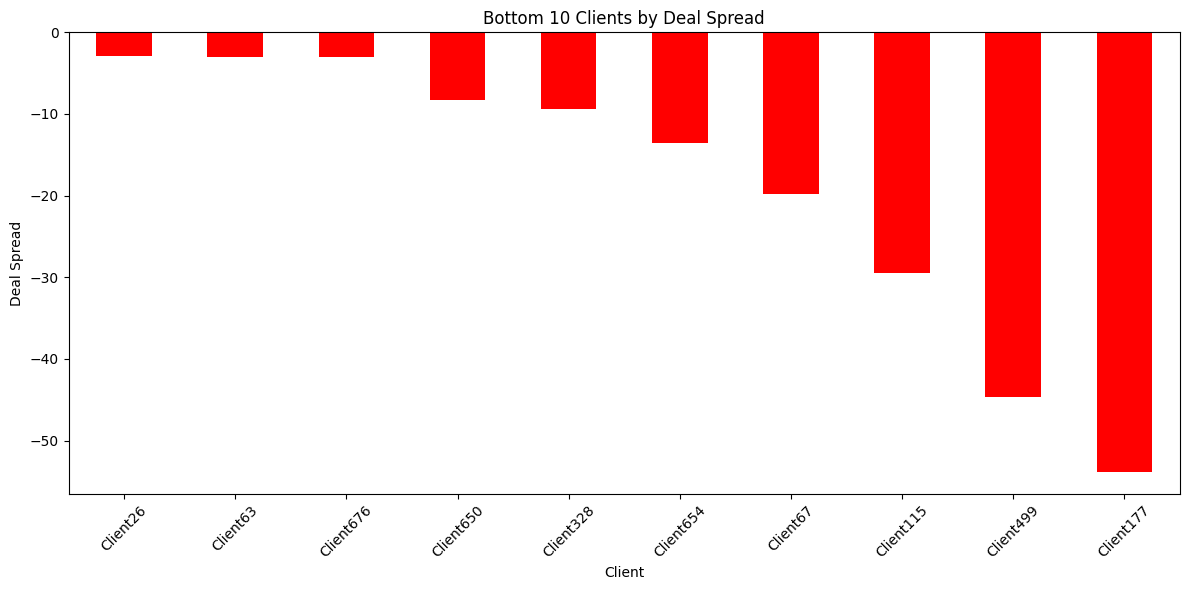

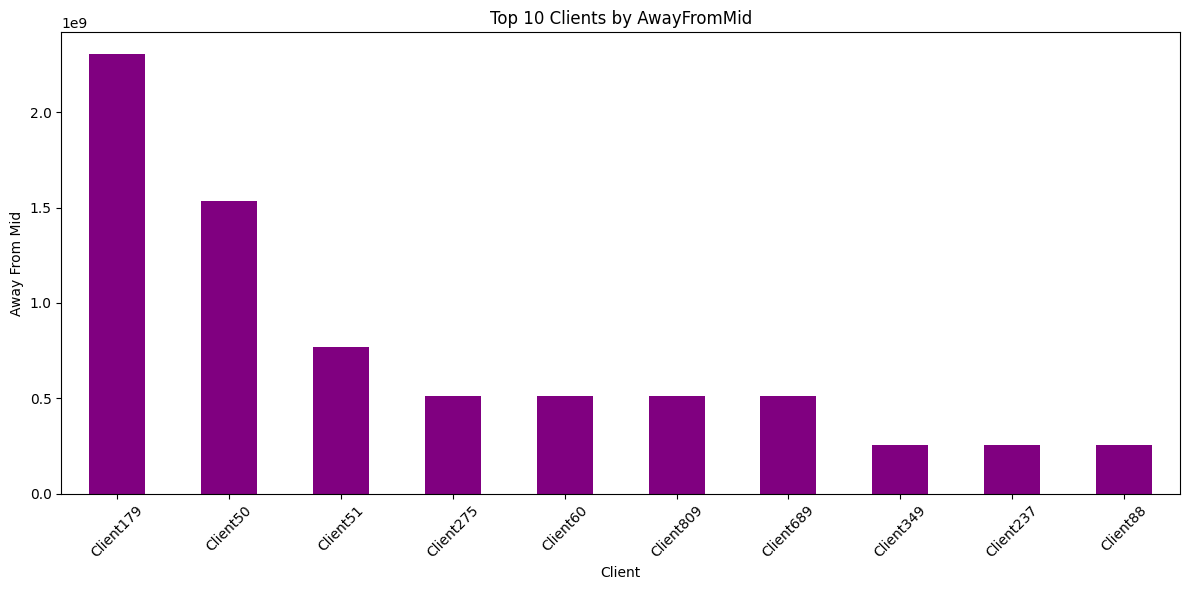

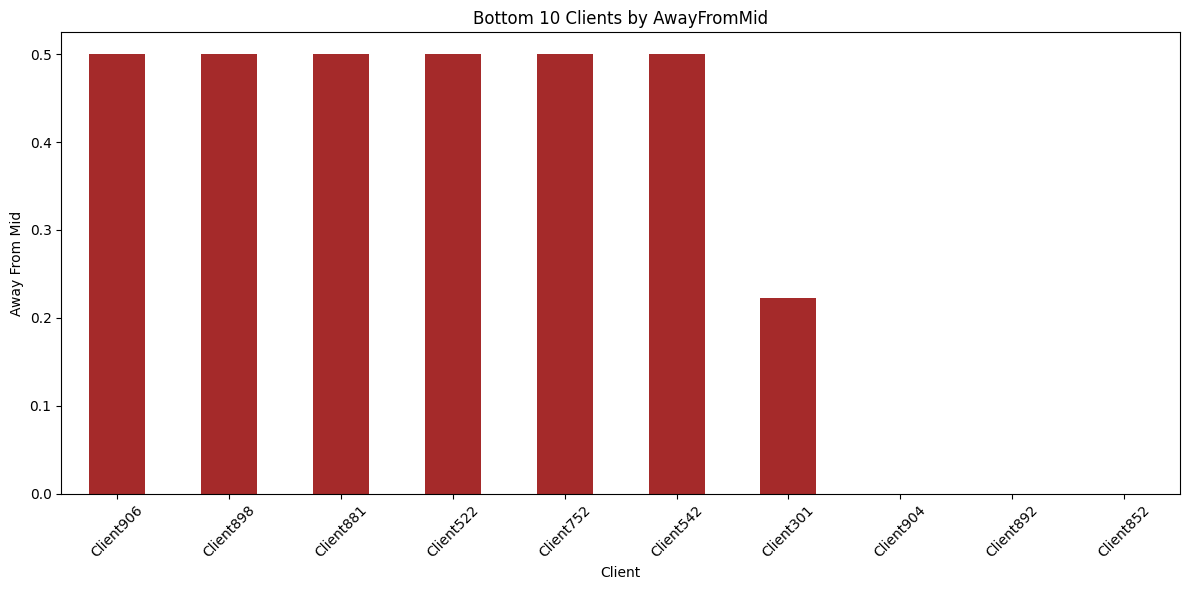

In [ ]:
top_n = 10
bottom_n = 10

sorted_clients_vol = df.groupby('Client')['Our Traded Vol'].sum().sort_values(ascending=False)
top_clients_vol = sorted_clients_vol.head(top_n)
bottom_clients_vol = sorted_clients_vol.tail(bottom_n)

# Plot the top clients by traded volume
plt.figure(figsize=(12, 6))
top_clients_vol.plot(kind='bar', title=f'Top {top_n} Clients by Traded Volume', color='blue')
plt.xlabel('Client')
plt.ylabel('Traded Volume')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot the bottom clients by traded volume
# plt.figure(figsize=(12, 6))
# bottom_clients_vol.plot(kind='bar', title=f'Bottom {bottom_n} Clients by Traded Volume', color='green')
# plt.xlabel('Client')
# plt.ylabel('Traded Volume')
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

# Similarly for deal spread
sorted_clients_spread = df.groupby('Client')['Deal Spread'].mean().sort_values(ascending=False)
top_clients_spread = sorted_clients_spread.head(top_n)
bottom_clients_spread = sorted_clients_spread.tail(bottom_n)

# Plot top clients by deal spread
plt.figure(figsize=(12, 6))
top_clients_spread.plot(kind='bar', title=f'Top {top_n} Clients by Deal Spread', color='orange')
plt.xlabel('Client')
plt.ylabel('Deal Spread')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot bottom clients by deal spread
plt.figure(figsize=(12, 6))
bottom_clients_spread.plot(kind='bar', title=f'Bottom {bottom_n} Clients by Deal Spread', color='red')
plt.xlabel('Client')
plt.ylabel('Deal Spread')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Similarly for AwayFromMid
sorted_clients_impact = df.groupby('Client')['AwayFromMid'].sum().sort_values(ascending=False)
top_clients_impact = sorted_clients_impact.head(top_n)
bottom_clients_impact = sorted_clients_impact.tail(bottom_n)

# Plot top clients by price impact
plt.figure(figsize=(12, 6))
top_clients_impact.plot(kind='bar', title=f'Top {top_n} Clients by AwayFromMid', color='purple')
plt.xlabel('Client')
plt.ylabel('Away From Mid')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot bottom clients by price impact
plt.figure(figsize=(12, 6))
bottom_clients_impact.plot(kind='bar', title=f'Bottom {bottom_n} Clients by AwayFromMid', color='brown')
plt.xlabel('Client')
plt.ylabel('Away From Mid')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Deal Spread and Market volume & Jefferies trade volume

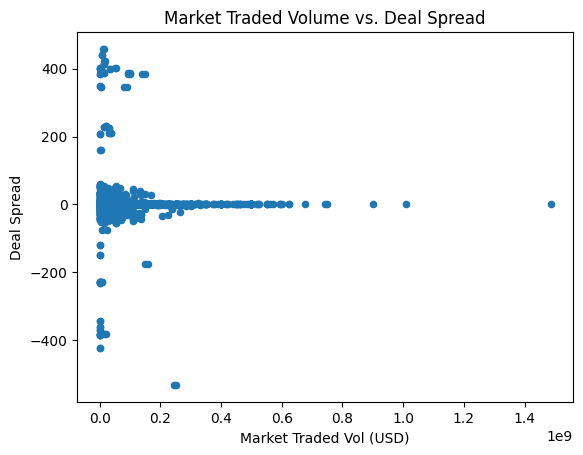

In [ ]:
# Scatter plot of Market Traded Volume vs. Deal Spread
df.plot.scatter(x='Market Traded Vol (USD)', y='Deal Spread', title='Market Traded Volume vs. Deal Spread')
plt.show()

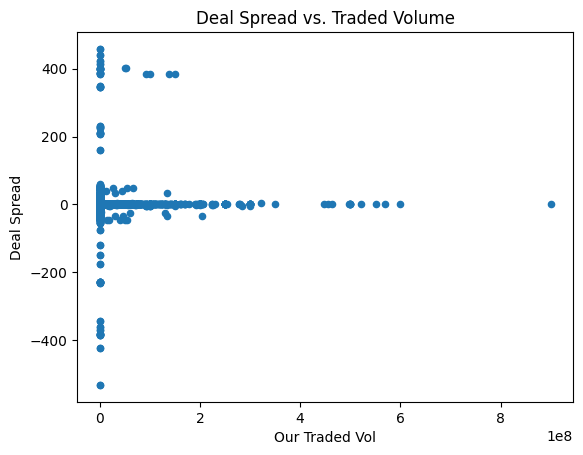

In [ ]:
# Scatter plot of Deal Spread vs. Our Traded Vol
df.plot.scatter(x='Our Traded Vol', y='Deal Spread', title='Deal Spread vs. Traded Volume')
plt.show()

# analyze this by Client or Trader
# df.groupby('Client').apply(lambda x: x.plot.scatter(x='Our Traded Vol', y='Deal Spread', title=f'Deal Spread vs. Traded Volume for {x.name}'))

<ipython-input-106-11ff4d4b670f>:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_deal_spread_by_volume = df.groupby('Volume Interval')['Deal Spread'].mean()
<ipython-input-106-11ff4d4b670f>:11: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['Volume Interval'] = df['Volume Interval'].replace('>1B', '100M-1B')
<ipython-input-106-11ff4d4b670f>:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  i

Volume Interval
1M-5M       29083
0-1M        18064
10M-100M     5819
5M-10M       2095
100M-1B       974
>1B             2
Name: count, dtype: int64


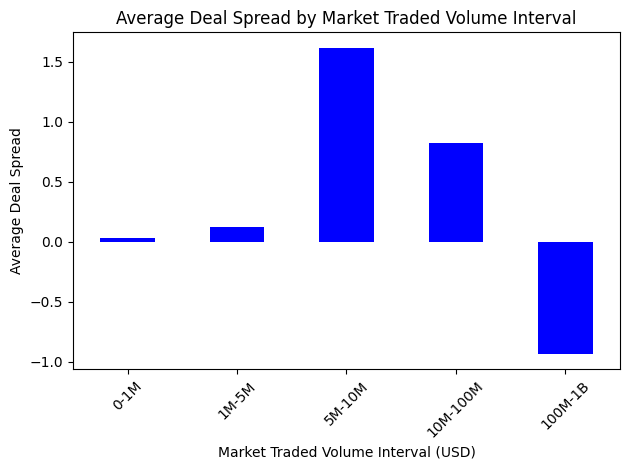

In [ ]:
# Market Traded Volume intervals
bins = [0, 1e6, 1e7, 1.5e7, 1e8, 1e9,df['Market Traded Vol (USD)'].max()]

df['Volume Interval'] = pd.cut(df['Market Traded Vol (USD)'], bins=bins, labels=['0-1M', '1M-5M', '5M-10M', '10M-100M', '100M-1B', '>1B'])

# calculate the average deal spread for each group
avg_deal_spread_by_volume = df.groupby('Volume Interval')['Deal Spread'].mean()

print(df['Volume Interval'].value_counts())

df['Volume Interval'] = df['Volume Interval'].replace('>1B', '100M-1B')

# average deal spread per interval
interval_spread = df.groupby('Volume Interval')['Deal Spread'].mean()

interval_spread.plot(kind='bar', color='blue', title='Average Deal Spread by Market Traded Volume Interval')
plt.xlabel('Market Traded Volume Interval (USD)')
plt.ylabel('Average Deal Spread')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## how settlement days affect deal success

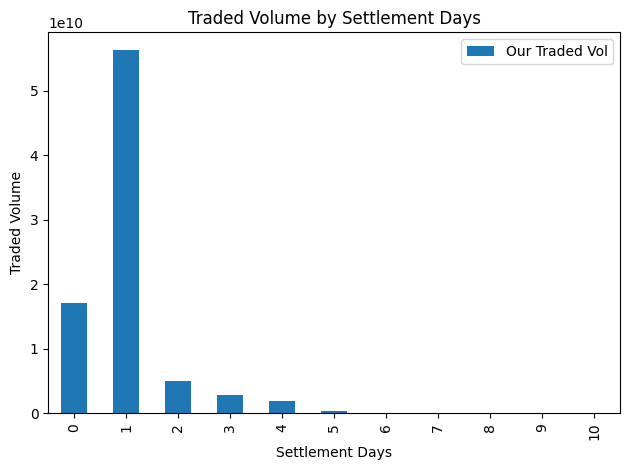

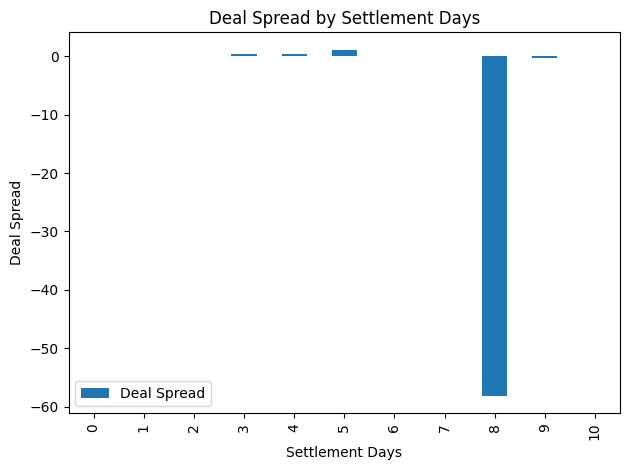

In [ ]:
# By Settlement Days to analyze how settlement days affect deal success
settlement_data = df.groupby('SettlementDays').agg({
    'Our Traded Vol': 'sum',
    'Deal Spread': 'mean',
    'First Response Time (Sec)': 'mean'
}).reset_index()

# Plot traded volume by Settlement Days
settlement_data.plot(kind='bar', x='SettlementDays', y='Our Traded Vol', title='Traded Volume by Settlement Days', xlabel='Settlement Days', ylabel='Traded Volume')
plt.tight_layout()
plt.show()

# Plot deal spread by Settlement Days
settlement_data.plot(kind='bar', x='SettlementDays', y='Deal Spread', title='Deal Spread by Settlement Days', xlabel='Settlement Days', ylabel='Deal Spread')
plt.tight_layout()
plt.show()

## Total Profit/Loss by Client for top clients

<Figure size 1200x600 with 0 Axes>

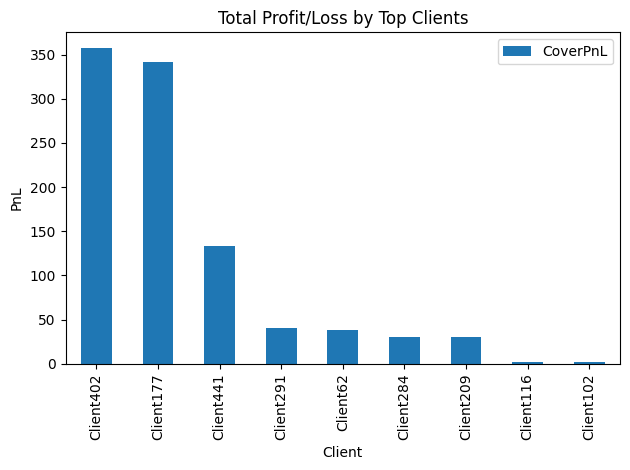

In [ ]:
# Client to analyze profitability
profitability_data = df.groupby('Client').agg({
    'CoverPnL': 'sum',  # Sum of profit/loss by client
    'Our Traded Vol': 'sum',  # Traded volume as a reference
}).reset_index()

# Limit the number of clients displayed (e.g., top 20 clients by PnL)
top_clients = profitability_data.sort_values(by='CoverPnL', ascending=False).head(9)

# Plot Total Profit/Loss by Client for top clients
plt.figure(figsize=(12, 6))
top_clients.plot(kind='bar', x='Client', y='CoverPnL', title='Total Profit/Loss by Top Clients', xlabel='Client', ylabel='PnL', legend=True)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
top_clients

,Client,CoverPnL,Our Traded Vol
337,Client402,357.286559,295396000
86,Client177,341.271907,180000000
379,Client441,133.392000,33348000
213,Client291,40.000000,10000000
577,Client62,38.364182,1405000000
205,Client284,30.640000,502530000
122,Client209,29.977500,8575000
19,Client116,2.010000,600000
4,Client102,1.777490,468055000


## how different instruments perform

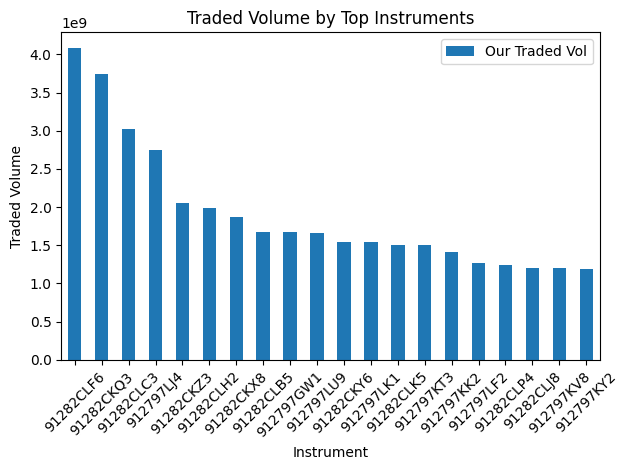

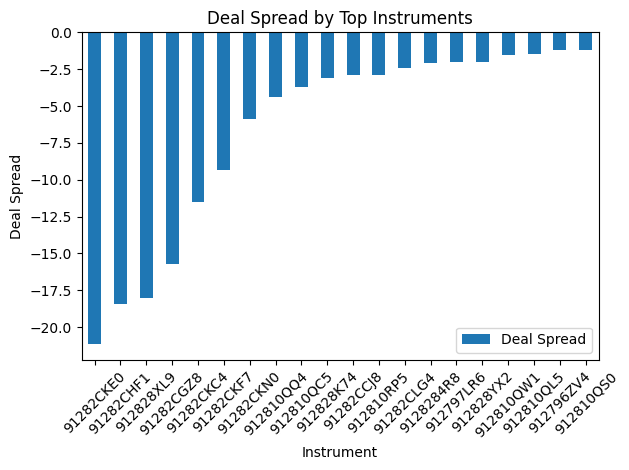

In [ ]:
# Aggregate data by Instrument
instrument_data = df.groupby('InstrumentCode').agg({
    'Our Traded Vol': 'sum',
    'Deal Spread': 'mean',
    'Best Bid Price': 'mean',
    'Best Ask Price': 'mean',
    'AwayFromMid': 'mean'
}).reset_index()


top_instruments = instrument_data.sort_values(by='Our Traded Vol', ascending=False).head(20)  # Change 20 to whatever number of top instruments you want to display

# traded volume by top instruments
top_instruments.plot(kind='bar', x='InstrumentCode', y='Our Traded Vol', title='Traded Volume by Top Instruments', xlabel='Instrument', ylabel='Traded Volume')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Sort by 'Deal Spread' to get top instruments based on deal spread
top_spread_instruments = instrument_data.sort_values(by='Deal Spread', ascending=True).head(20)

top_spread_instruments.plot(kind='bar', x='InstrumentCode', y='Deal Spread', title='Deal Spread by Top Instruments', xlabel='Instrument', ylabel='Deal Spread')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df['Customer_Accept'] = (df['ActionStr'] == 'CustAcceptedQuote').astype(int)
df['Dealer_Accept'] = (df['ActionStr'] == 'DealerAcceptOrder').astype(int)

In [ ]:
df['Bid_Ask_Spread'] = df['Best Ask Price'] - df['Best Bid Price']

In [ ]:
import pandas as pd
import statsmodels.api as sm

# Assuming 'df' is your DataFrame with necessary columns
# Strip any whitespace from column names
df.columns = df.columns.str.strip()

# Create 'Is_OnTheRun' as an indicator for On-the-Run bonds
df['Is_OnTheRun'] = (df['InstrumentSubGroup'] == 'ONTHERUN').astype(int)

# Create 'Customer_Accept' and 'Dealer_Accept' binary indicators
df['Customer_Accept'] = (df['ActionStr'] == 'CustAcceptedQuote').astype(int)
df['Dealer_Accept'] = (df['ActionStr'] == 'DealerAcceptOrder').astype(int)

# One-hot encode 'TradeSizeBucket' for different trade sizes
df = pd.get_dummies(df, columns=['TradeSizeBucket'], drop_first=True)

Column Bid-Ask Spread is missing from the DataFrame.


In [ ]:
print(df[['Deal Spread', 'Bid_Ask_Spread']])

       Deal Spread  Bid_Ask_Spread
0              0.0        0.023438
1              0.0        0.023438
2              0.0        0.007812
3              0.0        0.007812
4              0.0        0.015625
...            ...             ...
66676          0.0       -0.005000
66677          0.0       -0.005000
66678          0.0       -0.005000
66679          0.0        0.019531
66680          0.0       -0.050000

[66236 rows x 2 columns]


In [ ]:
# Verify if other required columns are present
additional_features = ['SettlementDays', 'Bid_Ask_Spread', 'Num of Dealers', 'First Response Time (Sec)']
for col in additional_features:
    if col not in df.columns:
        print(f"Column {col} is missing from the DataFrame.")

In [ ]:
# Grouping the DataFrame by Sector and MaturityBucket
grouped = df.groupby(['Sector', 'MaturityBucket'])


# Iterate over each group to run regression separately
# Iterate over each group to run regression separately
import pandas as pd
import statsmodels.api as sm
import numpy as np

# Iterate over each group to run regression separately
for (sector, maturity), group_data in grouped:
    # Ensure there are enough rows in the group to run regression
    if len(group_data) < 10:
        print(f"Not enough data for sector '{sector}' and maturity '{maturity}' to run regression.")
        continue

    # Prepare the feature matrix X and target vector y
    features = [
        'Is_OnTheRun', 'Our Traded Vol', 'Dealer_Accept', 'SettlementDays',
        'Num of Dealers', 'First Response Time (Sec)'
    ]

    # Add the one-hot encoded trade size columns
    #features += [col for col in df.columns if 'TradeSizeBucket_' in col]

    # Extract features for the current group
    X = group_data[features]
    y = group_data['Bid_Ask_Spread']

    # Convert all columns in X to numeric, coerce errors to NaN
    X = X.apply(pd.to_numeric, errors='coerce')
    y = pd.to_numeric(y, errors='coerce')

    # Convert bool columns to int
    for col in X.select_dtypes(include='bool').columns:
        X[col] = X[col].astype(int)

    # Drop rows with NaN values from both X and y
    X = X.dropna()
    y = y.loc[X.index]  # Ensure target vector matches the filtered feature set

    # Debug: Print out the data types of the columns in X and y
    print(f"Data types for Sector '{sector}' and Maturity '{maturity}':")
    print(X.dtypes)
    print("Target vector (y) dtype:", y.dtype)

    # Ensure there are no object dtypes left in X and y
    if any(X.dtypes == 'object') or y.dtype == 'object':
        print(f"Non-numeric data found for sector '{sector}' and maturity '{maturity}'. Skipping this group.")
        continue

    # Add a constant to the feature matrix for the intercept
    X = sm.add_constant(X)

    # Fit the OLS model if there are still sufficient rows after cleaning
    if len(X) < 10:
        print(f"Not enough clean data for sector '{sector}' and maturity '{maturity}' to run regression.")
        continue

    # Fit the OLS model
    try:
        model = sm.OLS(y, X).fit()
        # Print the summary for each group
        print(f"Regression results for Sector: '{sector}' and MaturityBucket: '{maturity}':")
        print(model.summary())
    except Exception as e:
        print(f"Error fitting model for sector '{sector}' and maturity '{maturity}': {e}")



Data types for Sector '0-1 YR' and Maturity '<18mos':
Is_OnTheRun                    int64
Our Traded Vol                 int64
Dealer_Accept                  int64
SettlementDays                 int64
Num of Dealers                 int64
First Response Time (Sec)    float64
dtype: object
Target vector (y) dtype: float64
Regression results for Sector: '0-1 YR' and MaturityBucket: '<18mos':
                            OLS Regression Results                            
Dep. Variable:         Bid_Ask_Spread   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     22.12
Date:                Tue, 22 Oct 2024   Prob (F-statistic):           4.51e-22
Time:                        01:53:05   Log-Likelihood:                 13520.
No. Observations:                7503   AIC:                        -2.703e+04
Df Residuals:                    7497   BIC:          

/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=11
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.10/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


Data types for Sector 'STRIPS' and Maturity '18m-2y':
Is_OnTheRun                    int64
Our Traded Vol                 int64
Dealer_Accept                  int64
SettlementDays                 int64
Num of Dealers                 int64
First Response Time (Sec)    float64
dtype: object
Target vector (y) dtype: float64
Regression results for Sector: 'STRIPS' and MaturityBucket: '18m-2y':
                            OLS Regression Results                            
Dep. Variable:         Bid_Ask_Spread   R-squared:                       0.188
Model:                            OLS   Adj. R-squared:                  0.098
Method:                 Least Squares   F-statistic:                     2.088
Date:                Tue, 22 Oct 2024   Prob (F-statistic):              0.182
Time:                        01:53:06   Log-Likelihood:                 23.947
No. Observations:                  11   AIC:                            -43.89
Df Residuals:                       9   BIC:          

/usr/local/lib/python3.10/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
/usr/local/lib/python3.10/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])



Is_OnTheRun                    int64
Our Traded Vol                 int64
Dealer_Accept                  int64
SettlementDays                 int64
Num of Dealers                 int64
First Response Time (Sec)    float64
dtype: object
Target vector (y) dtype: float64
Regression results for Sector: 'STRIPS' and MaturityBucket: '7y-10y':
                            OLS Regression Results                            
Dep. Variable:         Bid_Ask_Spread   R-squared:                       0.426
Model:                            OLS   Adj. R-squared:                  0.366
Method:                 Least Squares   F-statistic:                     7.060
Date:                Tue, 22 Oct 2024   Prob (F-statistic):            0.00510
Time:                        01:53:07   Log-Likelihood:                 51.259
No. Observations:                  22   AIC:                            -96.52
Df Residuals:                      19   BIC:                            -93.24
Df Model:                   

/usr/local/lib/python3.10/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=16
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=19
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.10/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


                            OLS Regression Results                            
Dep. Variable:         Bid_Ask_Spread   R-squared:                       0.110
Model:                            OLS   Adj. R-squared:                 -0.335
Method:                 Least Squares   F-statistic:                    0.2472
Date:                Tue, 22 Oct 2024   Prob (F-statistic):              0.932
Time:                        01:53:07   Log-Likelihood:                -31.399
No. Observations:                  16   AIC:                             74.80
Df Residuals:                      10   BIC:                             79.43
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [ ]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            Deal Spread   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                 -0.018
Method:                 Least Squares   F-statistic:                    0.2184
Date:                Tue, 22 Oct 2024   Prob (F-statistic):              0.804
Time:                        01:45:56   Log-Likelihood:                -494.32
No. Observations:                  91   AIC:                             994.6
Df Residuals:                      88   BIC:                             1002.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -8.4441      7.088     -1.

In [ ]:
customer_trades = df[df['ActionStr'] == 'CustAcceptedQuote']
dealer_trades = df[df['ActionStr'] == 'DealerAcceptOrder']

avg_spread_customer = customer_trades['Deal Spread'].mean()
avg_spread_dealer = dealer_trades['Deal Spread'].mean()

spread_premium_factor = (avg_spread_dealer - avg_spread_customer) / avg_spread_customer

df['Is_OnTheRun'] = (df['InstrumentSubGroup'] == 'ONTHERUN').astype(int)


grouped = df.groupby(['Is_OnTheRun', 'TradeSizeBucket', 'ActionStr'])
avg_spreads = grouped['Deal Spread'].mean().reset_index()

In [ ]:
import statsmodels.api as sm

# Prepare feature matrix
df['Dealer_Accept'] = (df['ActionStr'] == 'DealerAcceptOrder').astype(int)
X = df[['Is_OnTheRun', 'Our Traded Vol', 'Dealer_Accept']]
y = df['Deal Spread']

# Fit the model
X = sm.add_constant(X)  # Adds a constant term to the predictor matrix
model = sm.OLS(y, X).fit()

# Get the coefficient of Dealer_Accept to understand the impact
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            Deal Spread   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     9.090
Date:                Tue, 22 Oct 2024   Prob (F-statistic):           5.18e-06
Time:                        01:28:56   Log-Likelihood:            -2.5967e+05
No. Observations:               66236   AIC:                         5.194e+05
Df Residuals:                   66232   BIC:                         5.194e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.1375      0.062      2.

# Insight

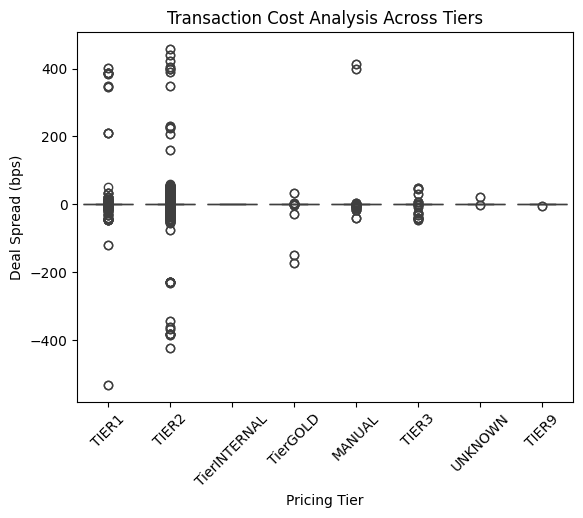

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Transaction Cost Analysis Across Tiers
sns.boxplot(data=df, x='Tier', y='Deal Spread')
plt.title('Transaction Cost Analysis Across Tiers')
plt.ylabel('Deal Spread (bps)')
plt.xlabel('Pricing Tier')
plt.xticks(rotation=45)
plt.show()

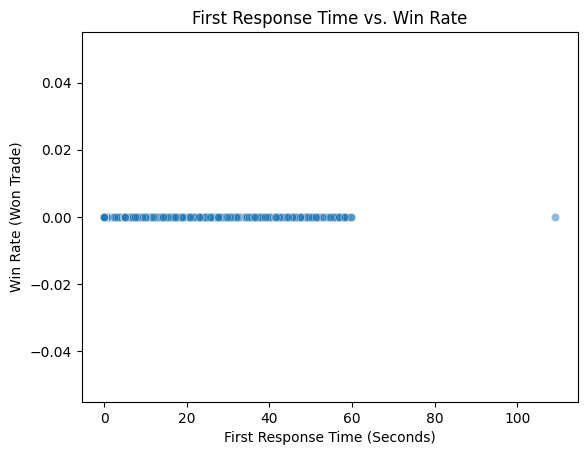

In [ ]:
# Response Time vs. Win Rate
df['WonTrade'] = df['RFQStatus'].apply(lambda x: 1 if x == 'WON' else 0)
sns.scatterplot(data=df, x='First Response Time (Sec)', y='WonTrade', alpha=0.5)
plt.title('First Response Time vs. Win Rate')
plt.ylabel('Win Rate (Won Trade)')
plt.xlabel('First Response Time (Seconds)')
plt.show()

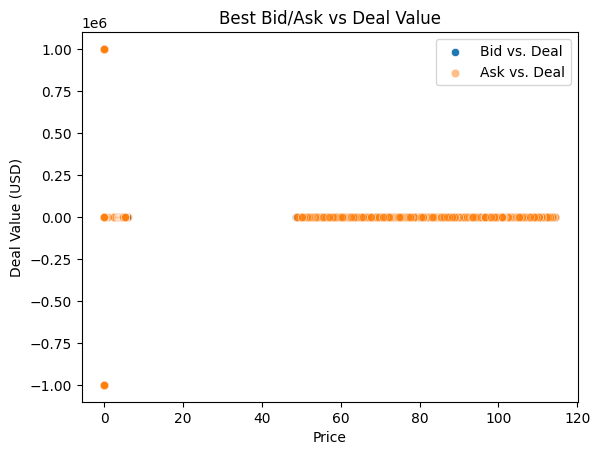

In [ ]:
# Best Bid/Ask vs Deal Value
sns.scatterplot(data=df, x='Best Bid Price', y='Deal Value', label='Bid vs. Deal')
sns.scatterplot(data=df, x='Best Ask Price', y='Deal Value', label='Ask vs. Deal', alpha=0.5)
plt.title('Best Bid/Ask vs Deal Value')
plt.ylabel('Deal Value (USD)')
plt.xlabel('Price')
plt.legend()
plt.show()

In [ ]:
# 5. Performance Across Markets and Maturity Buckets
sns.boxplot(data=df, x='Market', y='Deal Spread', hue='MaturityBucket')
plt.title('Transaction Cost Analysis by Market and Maturity Bucket')
plt.ylabel('Deal Spread (bps)')
plt.xlabel('Market')
plt.xticks(rotation=45)
plt.legend(title='Maturity Bucket', loc='upper right')
plt.show()

NameError: name 'sns' is not defined

In [ ]:
# 5. Performance Across Markets and Maturity Buckets
sns.boxplot(data=df, x='Market', y='Deal Spread', hue='MaturityBucket')
plt.title('Transaction Cost Analysis by Market and Maturity Bucket')
plt.ylabel('Deal Spread (bps)')
plt.xlabel('Market')
plt.xticks(rotation=45)
plt.legend(title='Maturity Bucket', loc='upper right')
plt.show()

# 6. RFQ Volume and Price Relationship by Tier and Sector
sns.scatterplot(data=df, x='Our Traded Vol', y='Deal Value', hue='Tier', style='Sector', alpha=0.6)
plt.title('RFQ Volume and Price Relationship by Tier and Sector')
plt.ylabel('Deal Value (USD)')
plt.xlabel('Our Traded Volume (Millions)')
plt.legend(title='Tier and Sector', loc='upper right')
plt.show()

# 7. Frequency Analysis for InstrumentSubGroup and Sector
subgroup_counts = df['InstrumentSubGroup'].value_counts()
sector_counts = df['Sector'].value_counts()

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
subgroup_counts.plot(kind='bar', color='skyblue')
plt.title('Frequency of Instrument Sub-Groups')
plt.xlabel('Instrument Sub-Group')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sector_counts.plot(kind='bar', color='lightgreen')
plt.title('Frequency of Sector')
plt.xlabel('Sector')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# 8. Deal Spread by SettlementDays (Are longer settlement trades more expensive?)
sns.boxplot(data=df, x='SettlementDays', y='Deal Spread')
plt.title('Deal Spread by Settlement Days')
plt.ylabel('Deal Spread (bps)')
plt.xlabel('Settlement Days')
plt.xticks(rotation=45)
plt.show()

# 9. Number of Quotes Analysis
sns.countplot(data=df, x='RFQNumberOfQuotes', hue='Tier')
plt.title('RFQ Number of Quotes by Tier')
plt.xlabel('Number of Quotes')
plt.ylabel('Frequency')
plt.legend(title='Tier', loc='upper right')
plt.show()

# 10. Winning Percentage by Client and Market
win_rate = df.groupby(['Client', 'Market'])['WonTrade'].mean().reset_index()
sns.heatmap(win_rate.pivot('Client', 'Market', 'WonTrade'), annot=True, cmap='coolwarm')
plt.title('Win Rate by Client and Market')
plt.ylabel('Client')
plt.xlabel('Market')
plt.show()

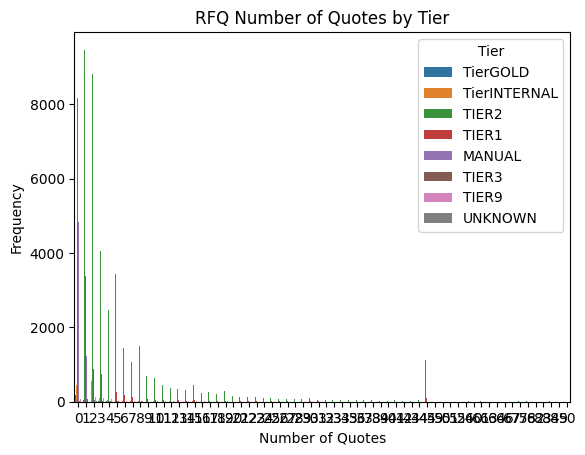

In [ ]:
# 9. Number of Quotes Analysis
sns.countplot(data=df, x='RFQNumberOfQuotes', hue='Tier')
plt.title('RFQ Number of Quotes by Tier')
plt.xlabel('Number of Quotes')
plt.ylabel('Frequency')
plt.legend(title='Tier', loc='upper right')
plt.show()

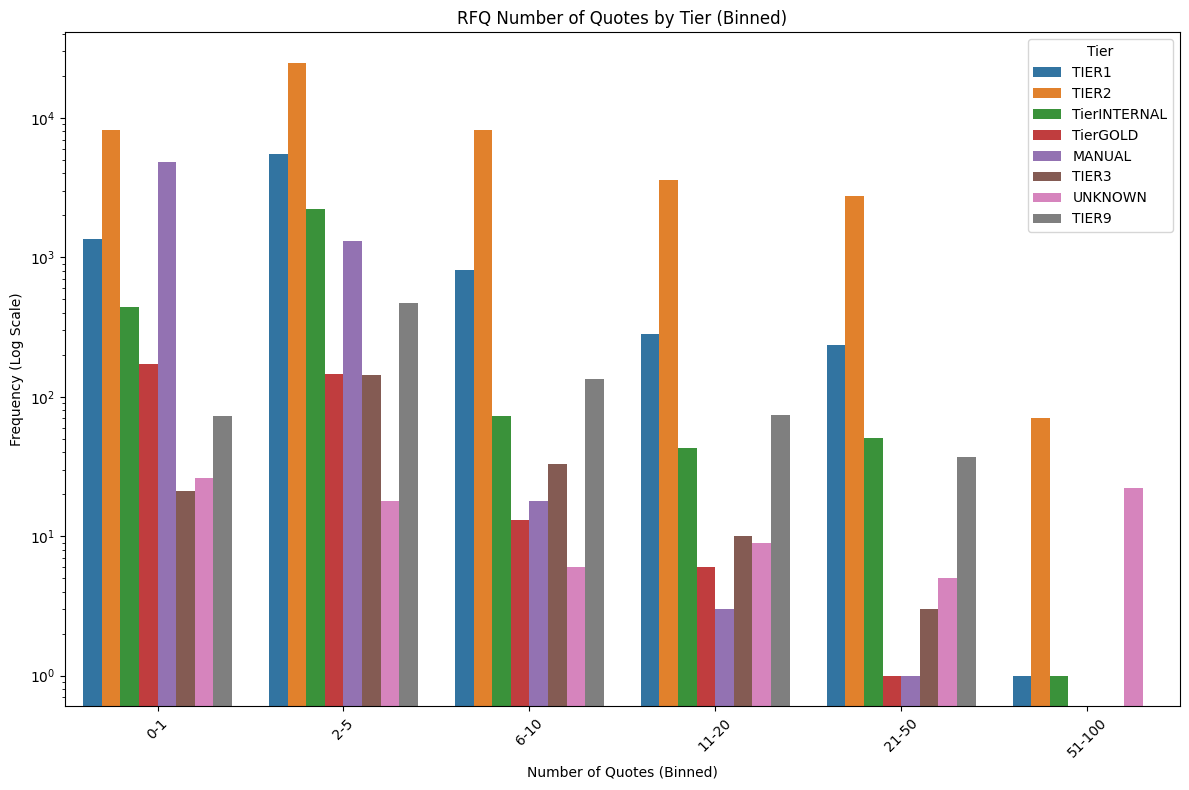

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assume df is the DataFrame with your data

# 1. Bin 'RFQNumberOfQuotes' to reduce clutter on x-axis
bins = [0, 1, 5, 10, 20, 50, 100]  # Define bins
labels = ['0-1', '2-5', '6-10', '11-20', '21-50', '51-100']
df['RFQNumberOfQuotes_Binned'] = pd.cut(df['RFQNumberOfQuotes'], bins=bins, labels=labels, right=False)

# 2. Create a count plot using the binned data
plt.figure(figsize=(12, 8))  # Increase figure size for better readability
sns.countplot(data=df, x='RFQNumberOfQuotes_Binned', hue='Tier', palette='tab10')

# 3. Log scale on y-axis (if needed)
plt.yscale('log')

# 4. Update labels and title
plt.title('RFQ Number of Quotes by Tier (Binned)')
plt.xlabel('Number of Quotes (Binned)')
plt.ylabel('Frequency (Log Scale)')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.legend(title='Tier', loc='upper right')

# 5. Show the plot
plt.tight_layout()
plt.show()

## Liquidity Features
### bid-ask spread

### Volume Metrics

In [ ]:
# Group by Sector and MaturityBucket and calculate price drift within each group
df['Price_Drift'] = df.groupby(['Sector', 'MaturityBucket'])['Mid Price'].transform(lambda x: x.shift(-1) - x)
df['Price_Drift']
#df['Adverse_Selection_Risk'] = (df['Price_Drift'] > threshold_value).astype(int)

,Price_Drift
0,0.093750
1,-1.958482
2,-0.035156
3,-0.269531
4,-2.871094
...,...
66676,0.000000
66677,0.000000
66678,0.022500
66679,NaN


In [ ]:
df['Price_Impact'] = (df['Mid Price'] - df['Deal Value']) / df['Mid Price']

In [ ]:
# Group by Sector and MaturityBucket and calculate VWAP within each group
def calculate_vwap(df):
    # VWAP calculation as sum(Price * Volume) / sum(Volume)
    return (df['Mid Price'] * df['Our Traded Vol']).sum() / df['Our Traded Vol'].sum()

# Apply the VWAP calculation to each group
df['VWAP'] = df.groupby(['Sector', 'MaturityBucket']).apply(lambda x: calculate_vwap(x)).reset_index(level=[0, 1], drop=True)

<ipython-input-21-b9bf0da59791>:4: RuntimeWarning: invalid value encountered in scalar divide
  return (df['Mid Price'] * df['Our Traded Vol']).sum() / df['Our Traded Vol'].sum()
<ipython-input-21-b9bf0da59791>:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df['VWAP'] = df.groupby(['Sector', 'MaturityBucket']).apply(lambda x: calculate_vwap(x)).reset_index(level=[0, 1], drop=True)


In [ ]:
df['Is_OnTheRun'] = (df['InstrumentSubGroup'] == 'ONTHERUN').astype(int)
df['Liquidity_Adjusted_Spread'] = df['Deal Spread'] * (1 + (1 - df['Is_OnTheRun']) * 0.2)
df['Liquidity_Volume_Interaction'] = df['Is_OnTheRun'] * df['Market Traded Vol (USD)']

In [ ]:
df['Tied_Win_Indicator'] = (df['TiedWonVol'] > 0).astype(int)

df['Competition_Score'] = df['TiedWonVol'] / df['Market Traded Vol (USD)']

In [ ]:
df['Price_Improvement_Tied'] = df['Mid Price'] - df['Cover']
df['Price_Improvement_Tied'] = df['Price_Improvement_Tied'] * df['Tied_Win_Indicator']

In [ ]:
print(df.columns)

Index(['let me tak', 'Id', 'Client', 'RFQStatus', 'InstrumentSubGroup',
       'Market Traded Vol (USD)', 'Our Traded Vol', 'TiedWonVol',
       'Num of Dealers', 'Trader', 'Sales', 'Covered Vol', 'Tier',
       'InstrumentCode', 'InstrumentDescription', 'AssetClass', 'Market',
       'LegNo', 'Maturity Date', 'RFQNumberOfQuotes', 'Buy/Sell',
       'Best Bid Price', 'Mid Price', 'Best Ask Price', 'Deal Value',
       'AwayFromMid', 'TickIdentifier', 'Deal Spread', 'Cover', 'CoverPnL',
       'SettlementDays', 'SettlementDate', 'SettlementStops', 'RFQ CreateTime',
       'RFQ ClosedTime', 'AnAutoReplyRFQs', 'First Response Time (Sec)',
       'TradeSizeBucket', 'Sector', 'MaturityBucket', 'Proximity_to_Event',
       'Bid_Ask_Spread', 'Rolling_Bid_Ask_Spread', 'Rolling_Traded_Vol',
       'Price_Drift', 'Price_Impact', 'VWAP', 'Is_OnTheRun',
       'Liquidity_Adjusted_Spread', 'Liquidity_Volume_Interaction',
       'Tied_Win_Indicator', 'Competition_Score', 'Price_Improvement_Tied',
  

In [ ]:
df.columns = df.columns.str.strip()
# Correct the column name if needed
df['Customer_Accept'] = (df['ActionStr'] == 'CustAcceptedQuote').astype(int)
df['Dealer_Accept'] = (df['ActionStr'] == 'DealerAcceptOrder').astype(int)


KeyError: 'ActionStr'

In [ ]:
# Check for column name and strip spaces
df.columns = df.columns.str.strip()

# Create dummy variables for ActionStr
df = pd.get_dummies(df, columns=['ActionStr'])

# One-hot encode the 'ActionStr' column
df = pd.get_dummies(df, columns=['ActionStr'])

# Create binary indicator columns for Customer_Accept and Dealer_Accept using the correct dummy variable names
df['Customer_Accept'] = df['ActionStr_CustAcceptedQuote'] if 'ActionStr_CustAcceptedQuote' in df.columns else 0
df['Dealer_Accept'] = df['ActionStr_DealerAcceptOrder'] if 'ActionStr_DealerAcceptOrder' in df.columns else 0

KeyError: "None of [Index(['ActionStr'], dtype='object')] are in the [columns]"

In [ ]:
df['OnTheRun_Customer_Accept'] = df['Is_OnTheRun'] * df['Customer_Accept']
df['OffTheRun_Dealer_Accept'] = (1 - df['Is_OnTheRun']) * df['Dealer_Accept']
